## Test Particle Shorter Timespan Run

Absolute one-armed amplitude and window length 1/2 the total time. Run for 2.6 Gyr

In [2]:
import numpy as np
import pyEXP
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.pyplot import cm
import cmasher as cmr
import pandas as pd
from astropy.table import Table, vstack
import scipy
import pickle

from functools import partial
from matplotlib import animation
from matplotlib.animation import FuncAnimation
%matplotlib inline
plt.rc('text', usetex=True)

import sys
sys.path.append('../../code/')
import importlib
import helper

In [3]:
# full_dat = np.loadtxt('../../data/mSSA_channels_Kiyan_test_t40-300/m1_amp_bins_j25_t16.dat')
# short_dat = full_dat[:160]
# np.savetxt('short_timespan_40-200_m1_amp_bins_j25_t16.dat', short_dat)

In [4]:
fname_m1_amp = 'short_timespan_40-200_m1_amp_bins_j25_t16.dat'

coefs_m1_amp0 = pyEXP.coefs.Coefs.factory(fname_m1_amp)

coefs_m1_amp = coefs_m1_amp0.deepcopy()

---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData


In [5]:
# A list with three keys.  Keys are integer arrays (or lists).  
# The first column of the data table has the key [0], etc.
#keylst = [[i] for i in range(len(coefs.getAllCoefs()))]

n_channels = int(len(coefs_m1_amp.getAllCoefs()))
times = coefs_m1_amp.Times()

keylst_m1_amp = [[i] for i in range(n_channels)]

config = {"snails_m1_amp": (coefs_m1_amp, keylst_m1_amp, [])}

# Window size is half the time series (a good default choice if it's practical)
window = int(len(times)/2)

# Only compute the first 50 PCs
npc = 60

flags = """
verbose: true
"""

mssa = pyEXP.mssa.expMSSA(config, window, npc, flags)

---- Eigen is using 4 threads


In [28]:
fig_dir = 'shorter_timespan_plots/'

In [7]:
ev = mssa.eigenvalues()

shape U = 33280 x 81
shape Y = 81 x 33280


In [8]:
coefs_m1_amp.zerodata()
mssa.reconstruct([*range(npc)])

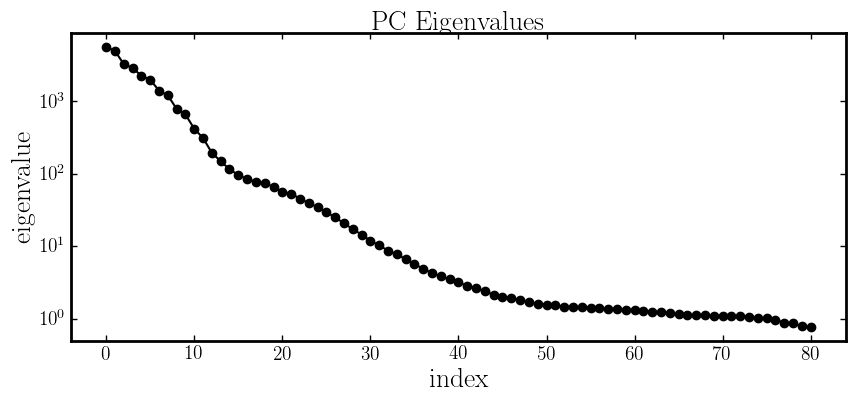

In [9]:
%matplotlib inline
fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))

ax1.semilogy(ev, '-o')

ax1.set_xlabel('index', fontsize=20)
ax1.set_ylabel('eigenvalue', fontsize=20)
    
ax1.set_title('PC Eigenvalues', fontsize=20)
#plt.savefig(fig_dir+'eigenvalues.pdf')
#plt.savefig(fig_dir+'eigenvalues.png')
plt.show()

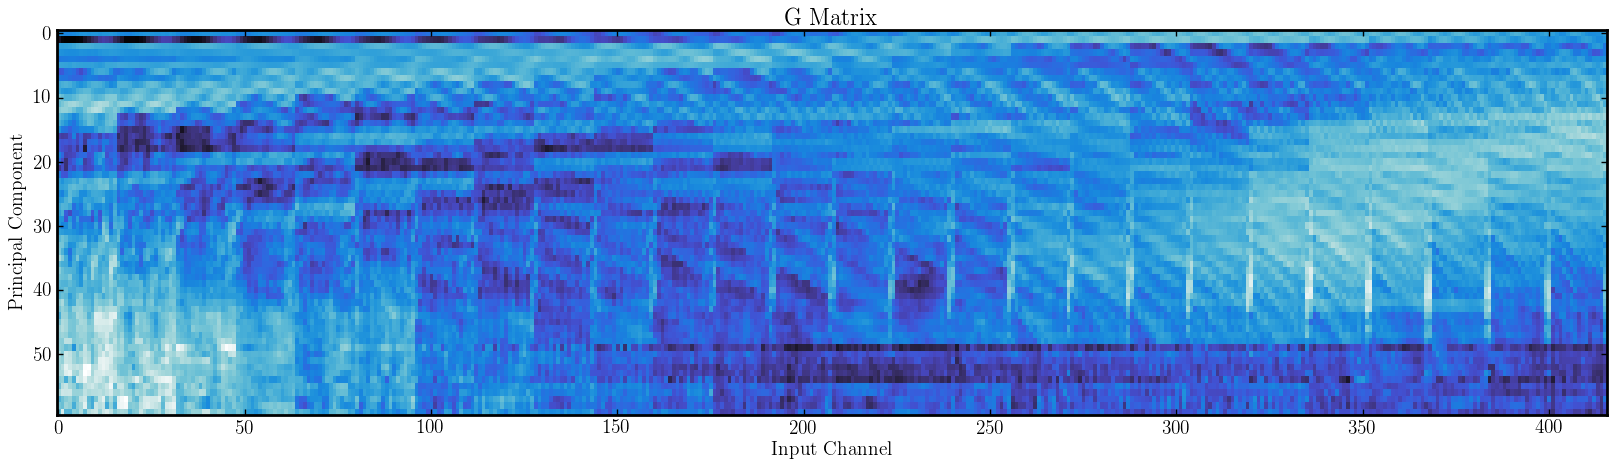

In [10]:
# t1 is each PCs contribution to each channel, t2 is each channels contribution to each PC
t1, t2 = mssa.contrib()
plt.figure(figsize=(20, 5))
plt.imshow(t2, aspect='auto', norm=mpl.colors.LogNorm(), cmap=cmr.freeze)
plt.xlabel('Input Channel')
plt.ylabel('Principal Component')
plt.title('G Matrix')
plt.show()

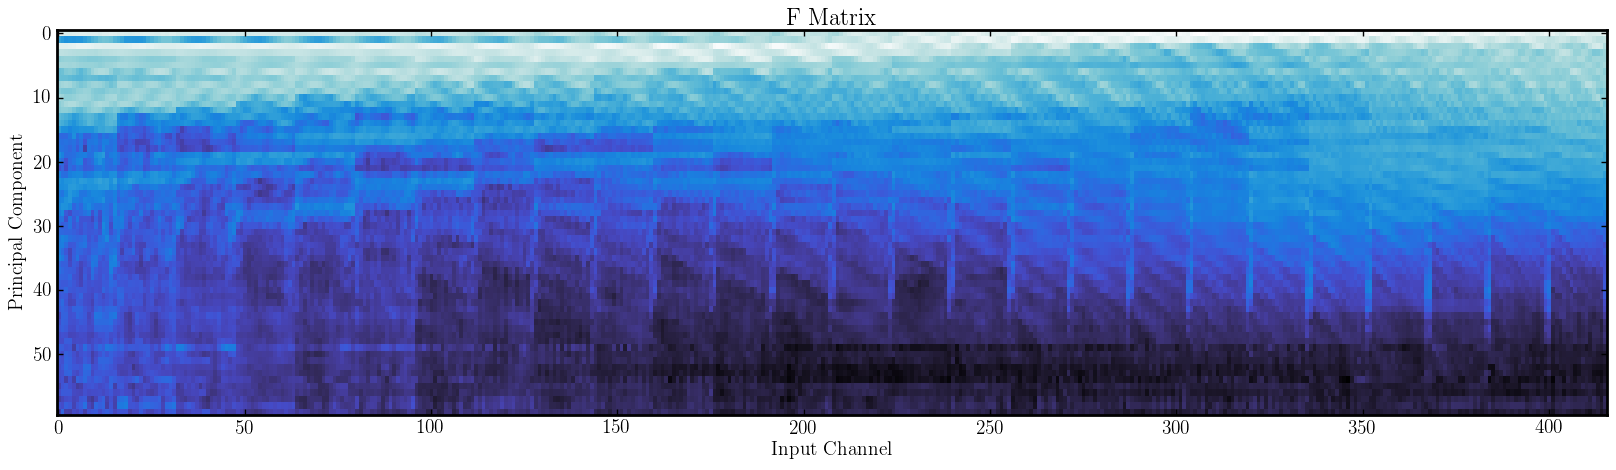

In [11]:
# t1 is each PCs contribution to each channel, t2 is each channels contribution to each PC
t1, t2 = mssa.contrib()
plt.figure(figsize=(20, 5))
plt.imshow(t1, aspect='auto', norm=mpl.colors.LogNorm(), cmap=cmr.freeze)
plt.xlabel('Input Channel')
plt.ylabel('Principal Component')
plt.title('F Matrix')
plt.show()

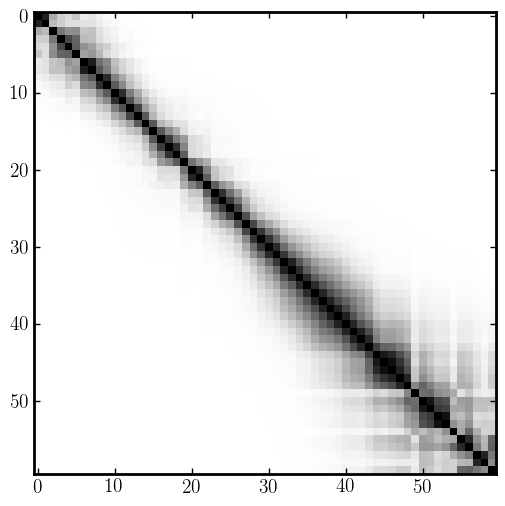

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(6,6), sharey=True)

ax.imshow(mssa.wCorrAll(), cmap='gray_r')
#plt.savefig(fig_dir+'wCorr30.pdf')
#plt.savefig(fig_dir+'wCorr30.png') 
plt.show()

(40.0, 144.0)

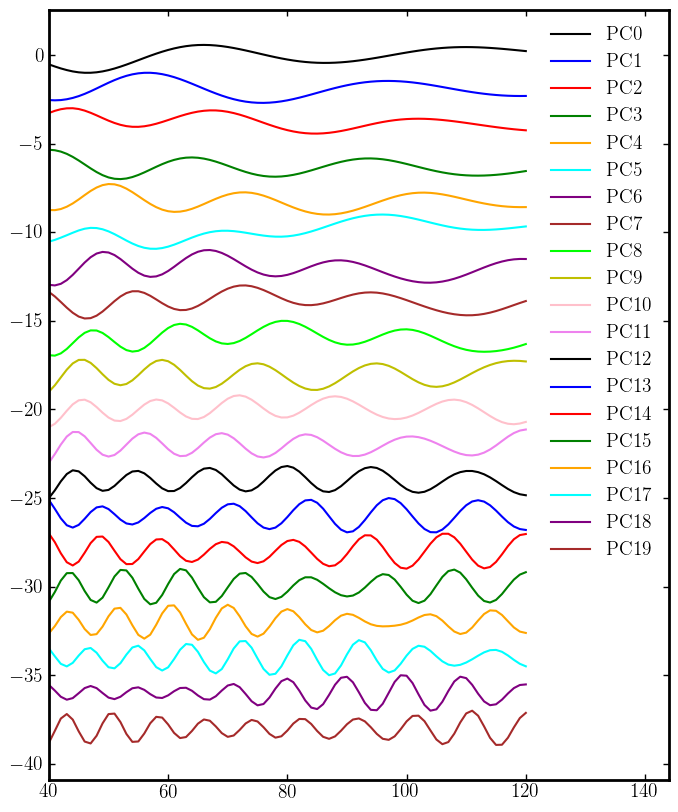

In [14]:
pc = mssa.getPC()

nt = pc.shape[0]
lag_times = times[:nt]

fig, ax = plt.subplots(1,1,figsize=(8,10))
for i in range(20):
    ax.plot(lag_times, pc[:,i] / np.max(np.abs(pc[:,i])) - 2*i, label='PC'+str(i))
ax.legend()
ax.set_xlim(np.min(lag_times), 1.2*np.max(lag_times))

In [16]:
freq, power = mssa.pcDFT()
freqs = np.load('../../data/test_frequency_array_j25.npy')

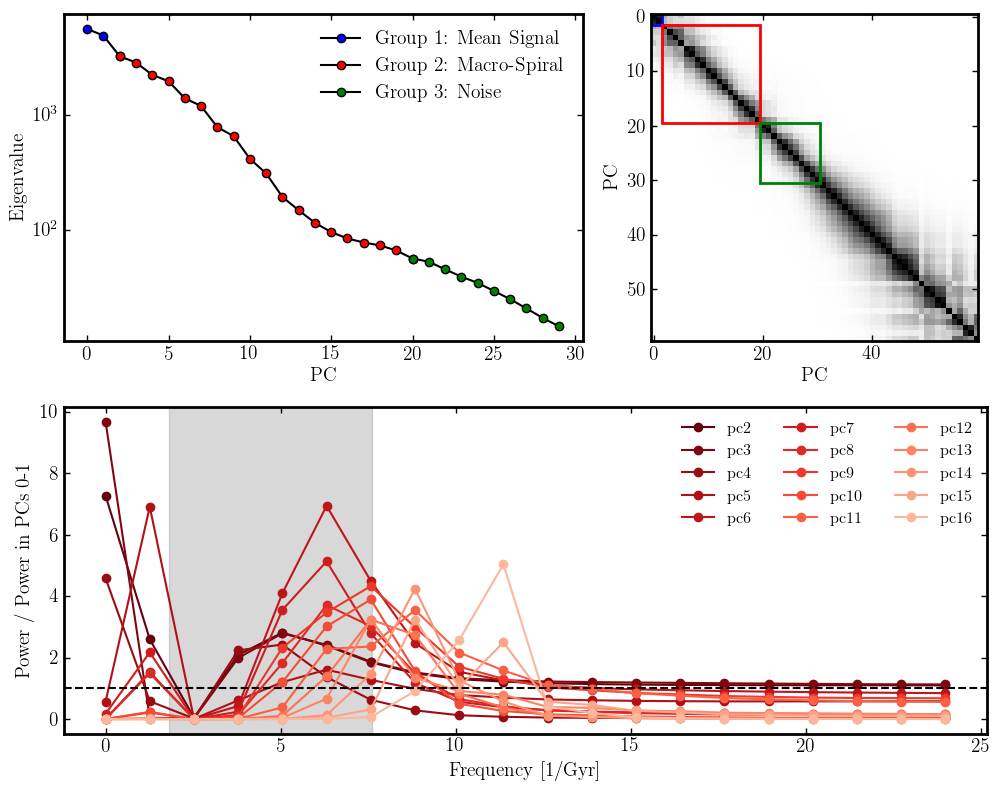

In [22]:
from matplotlib.patches import Rectangle
import matplotlib.gridspec as gridspec

eigenvalues = ev
cov_matrix = mssa.wCorrAll()

# Setting up the figure and gridspec
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(2, 3, width_ratios=[3, 2, 0.1], height_ratios=[1, 1], hspace=0.2, wspace=0.2, left=0.06, right=1.06, bottom=0.07, top=0.97)

# Top left: Eigenvalue plot (3/5 of the width)
ax1 = fig.add_subplot(gs[0, 0])
ax1.semilogy(np.arange(0,3), eigenvalues[:3], 'o-', label='Group 1: Mean Signal', c='k', mfc='blue')
ax1.semilogy(np.arange(2,21), eigenvalues[2:21], 'o-', label='Group 2: Macro-Spiral', c='k', mfc='red')
ax1.semilogy(np.arange(20, 30), eigenvalues[20:30], 'o-', label='Group 3: Noise', c='k', mfc='green')
ax1.set_xlabel('PC')
ax1.set_ylabel('Eigenvalue')
ax1.legend()

# Top right: Covariance Matrix (2/5 of the width)
ax2 = fig.add_subplot(gs[0, 1])
im = ax2.imshow(cov_matrix, cmap='gray_r')
ax2.set_xlabel('PC')
ax2.set_ylabel('PC')

# Highlighting groups in covariance plot
ax2.add_patch(Rectangle((-0.5, -0.5), 2, 2, fill=False, edgecolor='blue', lw=2))
ax2.add_patch(Rectangle((1.5, 1.5), 18, 18, fill=False, edgecolor='red', lw=2))
ax2.add_patch(Rectangle((19.5, 19.5), 11, 11, fill=False, edgecolor='green', lw=2))

# Bottom: Power spectrum plot
ax3 = fig.add_subplot(gs[1, :2])
color = iter(cm.Reds_r(np.linspace(0, 1, 20)))
for i in range(2, 17):
    c = next(color)
    ax3.plot(freq[:20] * (1/0.009778)/(2*np.pi), power[:20,i]/np.linalg.norm(power[:20,:2], axis=1), 'o-', c=c, label=f'pc{i}')
ax3.axhline(1.0, color='black', linestyle='--')
ax3.set_xlabel('Frequency [1/Gyr]')
ax3.set_ylabel('Power / Power in PCs 0-1')
ax3.axvspan(freqs[-1], freqs[0], alpha=0.3, color='gray')
ax3.legend(ncol=3, fontsize='small')

In [31]:
importlib.reload(sys.modules['helper'])
from helper import *

tbl_amp = np.loadtxt(fname_m1_amp)

f = fig_dir+'face-on_plots/data.mp4'
f_sub = fig_dir+'face-on_plots/data_subtract_pc0-1.mp4'

data = np.loadtxt(fname_m1_amp)
MakeAnim = MakeAnimations(mssa, sim_name='test', channel_name='one-armed amplitude', times=times, jphi_min=1000, jbins=26)
MakeAnim.make_data_mov(f, data, norm_function=mpl.colors.LogNorm, vmin=100, vmax=1e4, cmap=cmr.sunburst)

In [30]:
file_dir = fig_dir+'face-on_plots/'
vmin= 100 ; vmax=1e4

list_of_pc_lists = list(([0,1], [2,3], [4,5], [2,3,4,5],
                         list(range(2,20)), list(range(6,20)), 
                         list(range(21,30)), list(range(0,6)), 
                         list(range(0,10)), list(range(10,20)), list(range(0,20))
                        ))

for pc_list in list_of_pc_lists:
    MakeAnim.reconstruct_from_pcs(pcs=pc_list)
    MakeAnim.make_pc_reconstruction_mov(file_directory=file_dir, subtract_mean=False, 
                                        norm_function=mpl.colors.LogNorm, cmap=cmr.sunburst, vmin=vmin, vmax=vmax)
    MakeAnim.make_pc_reconstruction_mov(file_directory=file_dir, subtract_mean=True,
                                        norm_function=mpl.colors.SymLogNorm, cmap=cmr.prinsenvlag_r, vmin=-vmax, vmax=vmax, linthresh=vmin)

Updating for: (c)_0
Updating for: (s)_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (n)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (v)_0
Updating for: (A)_0
Updating for: (<)_0
Updating for: (k)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (X)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (@)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (n)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: ()_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0


### Rewind to a dipole

In [32]:
# To get colorbar
jphi_c = np.linspace(1000, 3500, 25+1)
tphi_c_ = np.linspace(0, 2*np.pi, 16+1)
rad = [0.5*(jphi_c[1] - jphi_c[0]), 0.5*(tphi_c_[1] - tphi_c_[0])]
tphi_c = tphi_c_[:-1] + rad[1]
J, T = np.meshgrid(jphi_c, tphi_c)

In [33]:
# Take Reconstructions

mssa.reconstruct(list(range(0,21)))
get_recon = mssa.getReconstructed()

recon_amp_ = get_recon[list(get_recon.keys())[0]].getAllCoefs()
recon_amp = recon_amp_ - np.mean(recon_amp_, axis=0)

#recon_pitch_ = get_recon[list(get_recon.keys())[1]].getAllCoefs()
#recon_pitch = recon_pitch_ - np.mean(recon_pitch_, axis=0)

# what is omega_phi at each radius, in rad/Gyr?
omega_phi = freqs*2*np.pi

time_diff = times[1]-times[0]

ratio = 0.01

Updating for: (c)_0
Updating for: (s)_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (n)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (j)_0
Updating for: (�)_0
Updating for: (?)_0
Updating for: (k)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (X)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (@)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (n)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: ()_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0


In [34]:
mssa.reconstruct(range(0,20))
get_recon = mssa.getReconstructed()
recon_amp_coefs = get_recon[list(get_recon.keys())[0]].getAllCoefs()
pc_rc = recon_amp_coefs

Updating for: ( )_0
Updating for: ()_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: (`)_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ()_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: (`)_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ()_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: (`)_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: (`)_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: (`)_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: (`)_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0


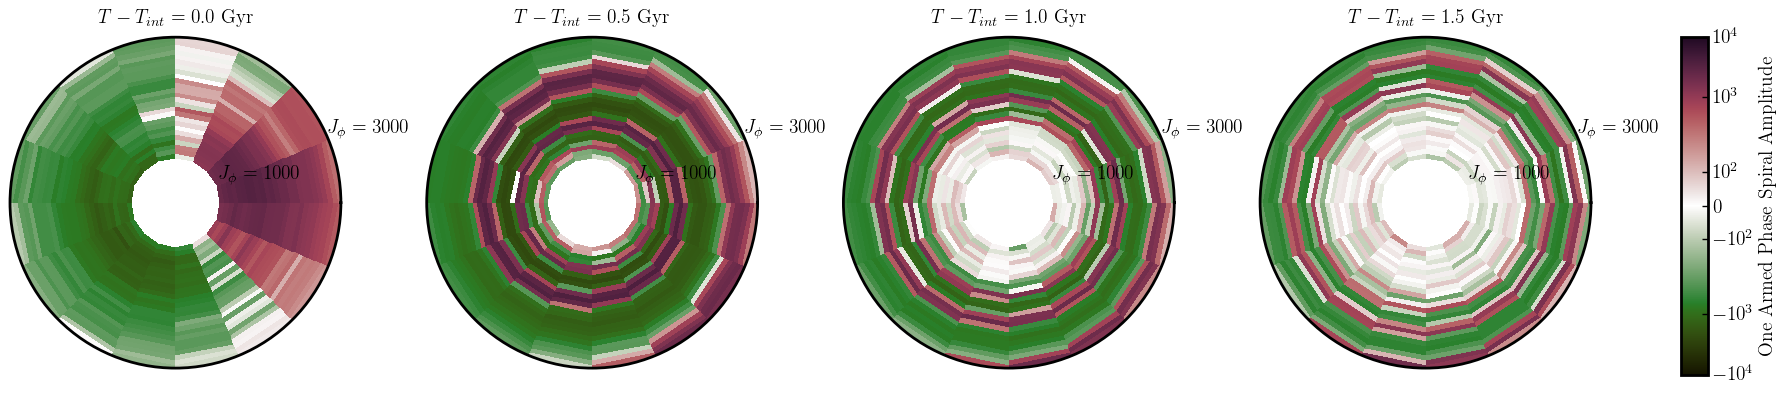

In [37]:
first_timestep = 0
fig, [ax1, ax2, ax3, ax4] = plt.subplots(1, 4, figsize=(18, 4.5), subplot_kw={'projection': 'polar'})

timestep=first_timestep+0
pc_rc_amp = pc_rc[:n_channels] 
pc_rc_amp = pc_rc_amp - np.mean(pc_rc_amp, axis=0)
rad_mean_amp = np.mean(np.reshape(pc_rc_amp[:,timestep], T.shape, 'F'), axis=0)
amp_vmax=1e4
cmap=cmr.holly

im1 = ax1.pcolormesh(T, J, np.reshape(pc_rc_amp[:,timestep], T.shape, 'F') - rad_mean_amp, 
                          cmap=cmap, rasterized=True,
                          norm=mpl.colors.SymLogNorm(linthresh=amp_vmax/50, 
                                                     vmin=-amp_vmax, 
                                                     vmax=amp_vmax))
ax1.set_title(r'$T - T_{int} = 0.0$ Gyr', pad=10, fontsize=14)



timestep=first_timestep+50
pc_rc_amp = pc_rc[:n_channels] 
pc_rc_amp = pc_rc_amp - np.mean(pc_rc_amp, axis=0)
rad_mean_amp = np.mean(np.reshape(pc_rc_amp[:,timestep], T.shape, 'F'), axis=0)

im2 = ax2.pcolormesh(T, J, np.reshape(pc_rc_amp[:,timestep], T.shape, 'F') - rad_mean_amp, 
                          cmap=cmap, rasterized=True,
                          norm=mpl.colors.SymLogNorm(linthresh=amp_vmax/50, 
                                                     vmin=-amp_vmax, 
                                                     vmax=amp_vmax))
ax2.set_title(r'$T - T_{int} = 0.5$ Gyr', pad=10, fontsize=14)



timestep=100
pc_rc_amp = pc_rc[:n_channels] 
pc_rc_amp = pc_rc_amp - np.mean(pc_rc_amp, axis=0)
rad_mean_amp = np.mean(np.reshape(pc_rc_amp[:,timestep], T.shape, 'F'), axis=0)

im3 = ax3.pcolormesh(T, J, np.reshape(pc_rc_amp[:,timestep], T.shape, 'F') - rad_mean_amp, 
                          cmap=cmap, rasterized=True,
                          norm=mpl.colors.SymLogNorm(linthresh=amp_vmax/50, 
                                                     vmin=-amp_vmax, 
                                                     vmax=amp_vmax))
ax3.set_title(r'$T - T_{int} = 1.0$ Gyr', pad=10, fontsize=14)


timestep=150
pc_rc_amp = pc_rc[:n_channels] 
pc_rc_amp = pc_rc_amp - np.mean(pc_rc_amp, axis=0)
rad_mean_amp = np.mean(np.reshape(pc_rc_amp[:,timestep], T.shape, 'F'), axis=0)

im5 = ax4.pcolormesh(T, J, np.reshape(pc_rc_amp[:,timestep], T.shape, 'F') - rad_mean_amp, 
                          cmap=cmap, rasterized=True,
                          norm=mpl.colors.SymLogNorm(linthresh=amp_vmax/50, 
                                                     vmin=-amp_vmax, 
                                                     vmax=amp_vmax))
ax4.set_title(r'$T - T_{int} = 1.5$ Gyr', pad=10, fontsize=14)

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_yticks([np.min(jphi_c), np.max(jphi_c)], labels=[r'$J_\phi=1000$', r'$J_\phi=3000$'])
    ax.set_rmax(np.max(jphi_c))
    ax.tick_params(left = False, right = False , labelleft = True ,
                         labelbottom = False, bottom = False)
    ax.grid(visible=False)

            

fig.tight_layout()


fig.subplots_adjust(right=0.89)
cbar_ax = fig.add_axes([0.94, 0.1, 0.015, 0.75])
cbar = fig.colorbar(im3, cax=cbar_ax)
cbar.set_label('One Armed Phase Spiral Amplitude')
# plt.savefig(fig_dir + 'm1_amplitudes_paper.pdf')
plt.show()

In [62]:
import importlib
from plot_helper import *
importlib.reload(sys.modules['plot_helper'])
from plot_helper import *

Updating for: (c)_0
Updating for: (s)_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (n)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (<)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (X)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (@)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (n)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: ()_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0


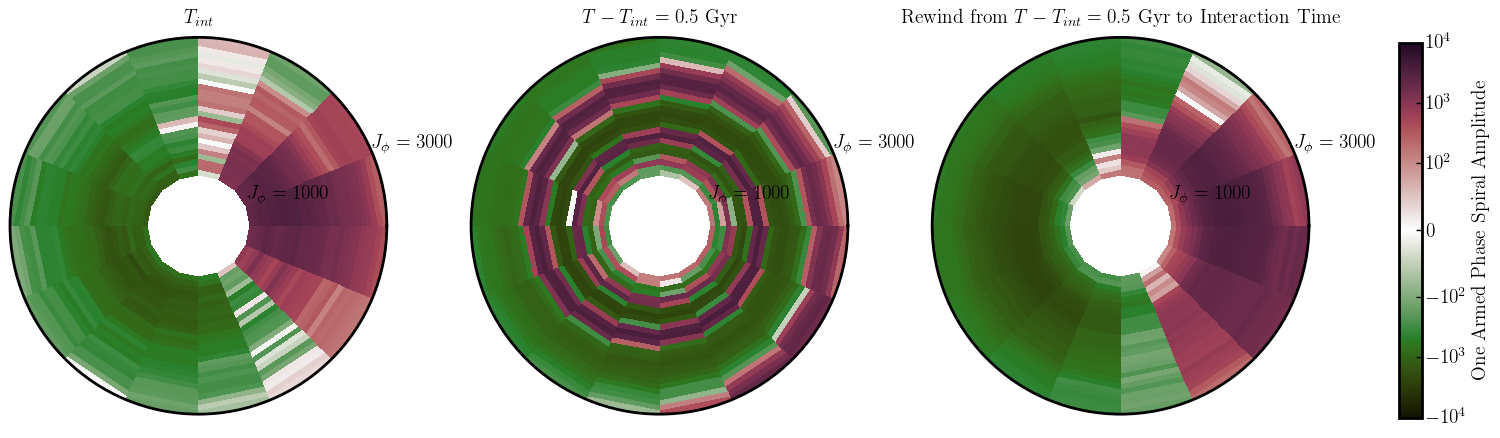

In [59]:
future_timestep = 50 #timesteps
dipole_timestep = 0
jbins=25

ratio = 0.01

mssa.reconstruct(list(range(0,20)))
get_recon = mssa.getReconstructed()
recon_amp_ = get_recon[list(get_recon.keys())[0]].getAllCoefs()
recon_amp = recon_amp_ - np.mean(recon_amp_, axis=0)

make_rewind_dipole_fig(dipole_timestep, future_timestep, recon_amp,
                       ratio = 0.01, axs=None)

Updating for: (c)_0
Updating for: (s)_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (n)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (*)_0
Updating for: (])_0
Updating for: (X)_0
Updating for: (k)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (X)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (@)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (n)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: ()_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0


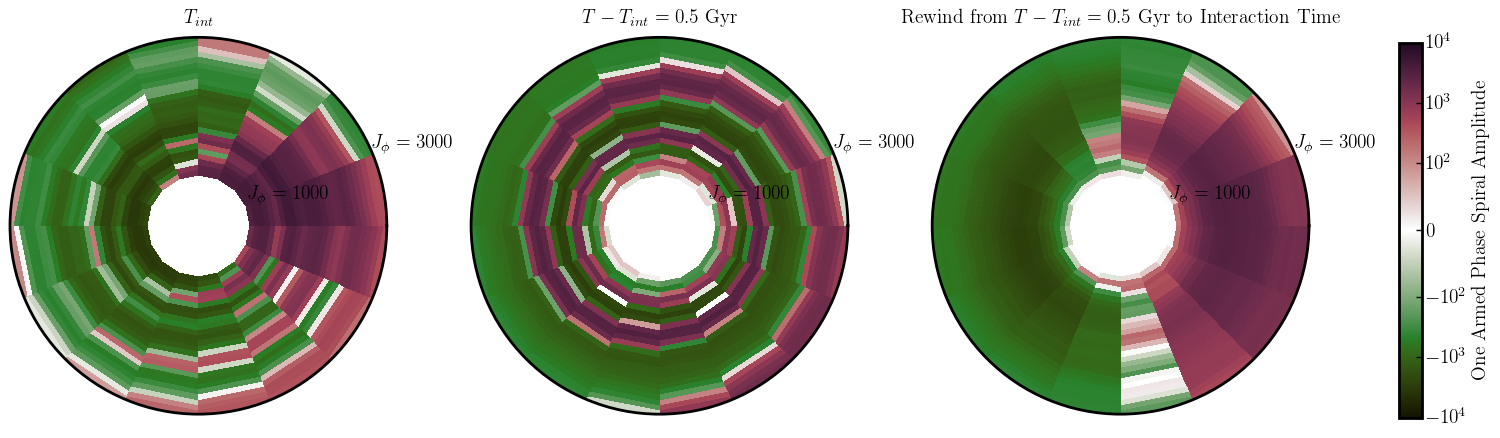

In [52]:
mssa.reconstruct(list(range(0,10)))
get_recon = mssa.getReconstructed()

recon_amp_ = get_recon[list(get_recon.keys())[0]].getAllCoefs()
recon_amp = recon_amp_ - np.mean(recon_amp_, axis=0)

make_rewind_dipole_fig(dipole_timestep, future_timestep, recon_amp,
                       ratio = 0.01, axs=None)

Updating for: (c)_0
Updating for: (s)_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (n)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ()_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (l)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (X)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (@)_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (n)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: ()_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0


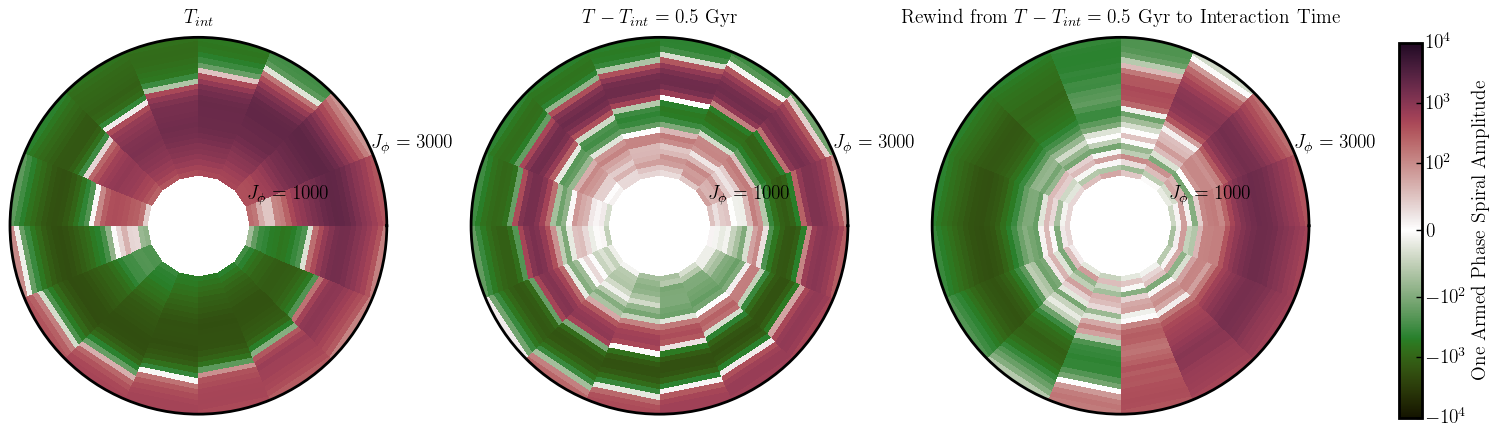

In [63]:
_ = mssa.reconstruct(list(range(0,2)))
get_recon = mssa.getReconstructed()

recon_amp_ = get_recon[list(get_recon.keys())[0]].getAllCoefs()
recon_amp = recon_amp_ - np.mean(recon_amp_, axis=0)

make_rewind_dipole_fig(dipole_timestep, future_timestep, recon_amp,
                       ratio = 0.01, axs=None)